Performed Exploratory Data Analysis (EDA) on three months of hotel booking data to understand revenue trends, guest behavior, and hotel performance. The work included data cleaning, validation, and preparation for analysis.

Analyzed revenue distribution, guest ratings, booking patterns, cancellations, and city- and hotel-level performance to uncover actionable insights. The analysis highlighted key revenue drivers, seasonal trends, high- and low-performing hotels, and opportunities to optimize operations, marketing strategies, and guest satisfaction.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
pd.options.display.float_format = '{:.2f}'.format
df_date = pd.read_csv('/Users/mustafafarooqui/DS Projects/Hospitality Domain/Datasets/dim_date.csv')
df_hotels = pd.read_csv('/Users/mustafafarooqui/DS Projects/Hospitality Domain/Datasets/dim_hotels.csv')
df_rooms = pd.read_csv('/Users/mustafafarooqui/DS Projects/Hospitality Domain/Datasets/dim_rooms.csv')
df_bookings = pd.read_csv('/Users/mustafafarooqui/DS Projects/Hospitality Domain/Datasets/fact_bookings.csv')
df_fact = pd.read_csv('/Users/mustafafarooqui/DS Projects/Hospitality Domain/Datasets/fact_aggregated_bookings.csv')

# Overview

In [3]:
print(df_date.shape)
print(df_date.duplicated().sum())
df_date.head()

(92, 4)
0


,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [4]:
df_date.isnull().sum()

date        0
mmm yy      0
week no     0
day_type    0
dtype: int64

In [5]:
print(df_hotels.shape)
print(df_hotels.duplicated().sum())
df_hotels.head()

(25, 4)
0


,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [6]:
df_hotels.isnull().sum()

property_id      0
property_name    0
category         0
city             0
dtype: int64

In [7]:
print(df_rooms.shape)
df_rooms.head()

(4, 2)


,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [8]:
print(df_fact.shape)
print(df_fact.duplicated().sum())
df_fact.head()

(9200, 5)
0


,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.00
1,19562,1-May-22,RT1,28,30.00
2,19563,1-May-22,RT1,23,30.00
3,17558,1-May-22,RT1,30,19.00
4,16558,1-May-22,RT1,18,19.00


In [9]:
df_fact.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
dtype: int64

In [10]:
print(df_bookings.shape)
df_bookings.head()

(134590, 12)


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.00,RT1,direct online,1.00,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.00,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.00,RT1,logtrip,5.00,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.00,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.00,RT1,direct online,5.00,Checked Out,10920,10920


In [11]:
df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                3
room_category            0
booking_platform         0
ratings_given        77907
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

In [12]:
df_bookings.duplicated().sum()

np.int64(0)

In [13]:
df_bookings['booking_id'].duplicated().sum()

np.int64(0)

In [14]:
df_bookings.dtypes

booking_id            object
property_id            int64
booking_date          object
check_in_date         object
checkout_date         object
no_guests            float64
room_category         object
booking_platform      object
ratings_given        float64
booking_status        object
revenue_generated      int64
revenue_realized       int64
dtype: object

**Data Cleaning**

In [15]:
df_fact.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.00
1,19562,1-May-22,RT1,28,30.00
2,19563,1-May-22,RT1,23,30.00
3,17558,1-May-22,RT1,30,19.00
4,16558,1-May-22,RT1,18,19.00


In [16]:
over_capacity = df_fact[df_fact['successful_bookings'] > df_fact['capacity']]
print(over_capacity.shape)
over_capacity.head()

(6, 5)


,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,1-May-22,RT1,30,19.00
12,16563,1-May-22,RT1,100,41.00
4136,19558,11-Jun-22,RT2,50,39.00
6209,19560,2-Jul-22,RT1,123,26.00
8522,19559,25-Jul-22,RT1,35,24.00


**Handling Over-Capacity Bookings**

During our data sanity check, we identified **6 rows where `successful_bookings` exceeded `capacity`**.  

After careful consideration, we decided **not to modify these rows**. The reason is rooted in real-world hotel operations:

- **Overbooking policies:** Many hotels intentionally overbook to account for cancellations or no-shows.  
**Conclusion:** These over-capacity bookings likely reflect real-world demand rather than data errors. We will retain them in our analysis, 

In [17]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.00,134587.00,56683.00,134590.00,134590.00
mean,18061.11,2.04,3.62,15378.05,12696.12
std,1093.06,1.03,1.24,93036.04,6928.11
min,16558.00,-17.00,1.00,6500.00,2600.00
25%,17558.00,1.00,3.00,9900.00,7600.00
50%,17564.00,2.00,4.00,13500.00,11700.00
75%,18563.00,2.00,5.00,18000.00,15300.00
max,19563.00,6.00,5.00,28560000.00,45220.00


During data cleaning, a few records had negative values in the `no_guests` column, which is logically impossible. These values were treated as outliers and removed to maintain data integrity.

In [18]:
df_bookings[df_bookings['no_guests'] < 0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.00,RT1,direct online,1.00,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.00,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.00,RT4,direct online,NaN,No Show,20900,20900
18020,May122218561RT22,18561,8/5/2022,12/5/2022,14-05-22,-12.00,RT2,makeyourtrip,NaN,Cancelled,9000,3600
18119,May122218562RT311,18562,5/5/2022,12/5/2022,17-05-22,-6.00,RT3,direct offline,5.00,Checked Out,16800,16800
18121,May122218562RT313,18562,10/5/2022,12/5/2022,17-05-22,-4.00,RT3,direct online,NaN,Cancelled,14400,5760
56715,Jun082218562RT12,18562,5/6/2022,8/6/2022,13-06-22,-17.00,RT1,others,NaN,Checked Out,6500,6500
119765,Jul202219560RT220,19560,19-07-22,20-07-22,22-07-22,-1.00,RT2,others,NaN,Checked Out,13500,13500
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.00,RT4,logtrip,2.00,Checked Out,38760,38760


Total, 9 records contained negative values in the number_of_guests field, which is invalid. These records also had missing values in the rating column. Since these rows represented only 0.007% of the dataset, they were removed to maintain data integrity.

In [19]:
df_bookings = df_bookings[df_bookings['no_guests']>= 0].reset_index(drop=True)

# Conformation

print(df_bookings.shape)
df_bookings[df_bookings['no_guests'] < 0]

(134578, 12)


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized


In [20]:
df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77899
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

During data exploration, the `rating` column was found to contain 77,899 missing values (≈57% of the dataset). This is common in hotel management systems, as many guests do not leave reviews after their stay. Therefore, these values were retained as NaN and excluded only during rating-related analysis.


In [21]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134578.00,134578.00,56679.00,134578.00,134578.00
mean,18061.14,2.04,3.62,15378.04,12696.01
std,1093.05,1.03,1.23,93040.15,6927.84
min,16558.00,1.00,1.00,6500.00,2600.00
25%,17558.00,1.00,3.00,9900.00,7600.00
50%,17564.00,2.00,4.00,13500.00,11700.00
75%,18563.00,2.00,5.00,18000.00,15300.00
max,19563.00,6.00,5.00,28560000.00,45220.00


The `revenue_generated` column contains some extreme values that are much higher than typical bookings, indicating the presence of outliers.

In [22]:
def transform_outliers(group):
    Q1 = group['revenue_generated'].quantile(0.25)
    Q3 = group['revenue_generated'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    group['revenue_generated'] = group['revenue_generated'].clip(lower, upper)
    return group

df_bookings = df_bookings.groupby('room_category', group_keys=False).apply(transform_outliers)
df_bookings.describe()

/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/760563595.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_bookings = df_bookings.groupby('room_category', group_keys=False).apply(transform_outliers)


,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134578.00,134578.00,56679.00,134578.00,134578.00
mean,18061.14,2.04,3.62,14913.99,12696.01
std,1093.05,1.03,1.23,6448.31,6927.84
min,16558.00,1.00,1.00,6500.00,2600.00
25%,17558.00,1.00,3.00,9900.00,7600.00
50%,17564.00,2.00,4.00,13500.00,11700.00
75%,18563.00,2.00,5.00,18000.00,15300.00
max,19563.00,6.00,5.00,45220.00,45220.00


During data cleaning, the extreme values in the `revenue_generated` column were carefully examined. Instead of applying a global outlier detection across all bookings, we segmented the data by `room_type` because different room categories naturally have different pricing ranges. Outliers were identified within each room type using the IQR method.  

We chose **IQR-based detection per room type** over global standard deviation or median replacement because:  

- Global statistics would misclassify valid high-priced bookings in luxury rooms as outliers.  
- Median replacement would distort actual revenue values, potentially hiding meaningful business insights.  
- The IQR method respects the natural distribution of revenue for each room category while accurately highlighting unusual bookings.

In [23]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134578.00,134578.00,56679.00,134578.00,134578.00
mean,18061.14,2.04,3.62,14913.99,12696.01
std,1093.05,1.03,1.23,6448.31,6927.84
min,16558.00,1.00,1.00,6500.00,2600.00
25%,17558.00,1.00,3.00,9900.00,7600.00
50%,17564.00,2.00,4.00,13500.00,11700.00
75%,18563.00,2.00,5.00,18000.00,15300.00
max,19563.00,6.00,5.00,45220.00,45220.00


**Data Transformation**

In [24]:
df_fact['check_in_date'] = pd.to_datetime(
    df_fact['check_in_date'],
    dayfirst=True,
    errors='coerce'
)

for col in ['booking_date', 'check_in_date', 'checkout_date']:
    df_bookings[col] = pd.to_datetime(
        df_bookings[col],
        format='mixed',
        dayfirst=True,
        errors='coerce'
)

# df_date['date'] = df_date['date'].astype(str).str.strip()

df_date['date'] = pd.to_datetime(
    df_date['date'],
    dayfirst=True, 
    errors='coerce'
)

/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/1469108902.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_fact['check_in_date'] = pd.to_datetime(
/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/1469108902.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_date['date'] = pd.to_datetime(


Mixed date formats were standardized across three datasets to allow seamless combination of booking, capacity, performance, and other dimensional data for in-depth analysis

In [25]:
# Data Merging

df_bookings = df_bookings.merge(
    df_rooms,
    left_on='room_category',
    right_on='room_id',
    how='left'
)
df_bookings.drop('room_id', axis=1, inplace=True)

df_bookings = df_bookings.merge(df_hotels, on='property_id', how='left')

df_bookings = df_bookings.merge(
    df_fact,
    on=['property_id', 'check_in_date', 'room_category'],
    how='left'
)

df_bookings = df_bookings.merge(
    df_date,
    left_on='check_in_date',
    right_on='date',
    how='left'
)

df_bookings.drop('date', axis=1, inplace=True)

print(df_bookings.shape)
df_bookings.head()

(134578, 21)


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,...,revenue_realized,room_class,property_name,category,city,successful_bookings,capacity,mmm yy,week no,day_type
0,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2.00,RT1,others,NaN,Cancelled,...,3640,Standard,Atliq Grands,Luxury,Delhi,18,19.00,May 22,W 19,weekend
1,May012216558RT13,16558,2022-04-28,2022-05-01,2022-05-04,2.00,RT1,logtrip,5.00,Checked Out,...,9100,Standard,Atliq Grands,Luxury,Delhi,18,19.00,May 22,W 19,weekend
2,May012216558RT15,16558,2022-04-27,2022-05-01,2022-05-02,4.00,RT1,direct online,5.00,Checked Out,...,10920,Standard,Atliq Grands,Luxury,Delhi,18,19.00,May 22,W 19,weekend
3,May012216558RT16,16558,2022-05-01,2022-05-01,2022-05-03,2.00,RT1,others,4.00,Checked Out,...,9100,Standard,Atliq Grands,Luxury,Delhi,18,19.00,May 22,W 19,weekend
4,May012216558RT17,16558,2022-04-28,2022-05-01,2022-05-06,2.00,RT1,others,NaN,Cancelled,...,3640,Standard,Atliq Grands,Luxury,Delhi,18,19.00,May 22,W 19,weekend


**Data Integration for Exploratory Analysis**

To prepare for exploratory analysis, multiple datasets were merged into a single comprehensive dataset. Booking data was first combined with room information to align categories, followed by enriching it with hotel details to provide property-level context. Operational metrics from the fact table were then incorporated to include capacity and performance insights, and finally, date attributes were added to capture temporal features. The resulting dataset brings together booking, room, hotel, performance, and date information in one unified table, ready for deeper analysis.

In [26]:
df_bookings.isnull().sum()

booking_id                 0
property_id                0
booking_date               0
check_in_date              0
checkout_date              0
no_guests                  0
room_category              0
booking_platform           0
ratings_given          77899
booking_status             0
revenue_generated          0
revenue_realized           0
room_class                 0
property_name              0
category                   0
city                       0
successful_bookings        0
capacity                  34
mmm yy                     0
week no                    0
day_type                   0
dtype: int64

The 2 NaNs in capacity from df_fact became 34 after the merge because each df_fact row was duplicated across multiple bookings in df_bookings with the same property_id, room_category, and check_in_date; this is normal behavior in a left merge."

**Exploratory Data Analysis**

In [27]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,...,revenue_realized,room_class,property_name,category,city,successful_bookings,capacity,mmm yy,week no,day_type
0,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2.00,RT1,others,NaN,Cancelled,...,3640,Standard,Atliq Grands,Luxury,Delhi,18,19.00,May 22,W 19,weekend
1,May012216558RT13,16558,2022-04-28,2022-05-01,2022-05-04,2.00,RT1,logtrip,5.00,Checked Out,...,9100,Standard,Atliq Grands,Luxury,Delhi,18,19.00,May 22,W 19,weekend
2,May012216558RT15,16558,2022-04-27,2022-05-01,2022-05-02,4.00,RT1,direct online,5.00,Checked Out,...,10920,Standard,Atliq Grands,Luxury,Delhi,18,19.00,May 22,W 19,weekend
3,May012216558RT16,16558,2022-05-01,2022-05-01,2022-05-03,2.00,RT1,others,4.00,Checked Out,...,9100,Standard,Atliq Grands,Luxury,Delhi,18,19.00,May 22,W 19,weekend
4,May012216558RT17,16558,2022-04-28,2022-05-01,2022-05-06,2.00,RT1,others,NaN,Cancelled,...,3640,Standard,Atliq Grands,Luxury,Delhi,18,19.00,May 22,W 19,weekend


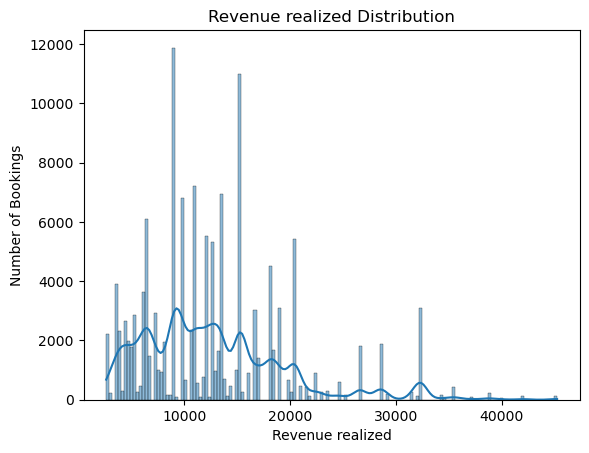

In [28]:
sns.histplot(df_bookings['revenue_realized'], bins=150, kde=True)
plt.title('Revenue realized Distribution')
plt.xlabel('Revenue realized')
plt.ylabel('Number of Bookings')
plt.savefig("my_plot1.png")
plt.show()

***Revenue Distribution Insights***

Exploring the distribution of revenue_realized reveals a classic right-skewed pattern. Most bookings cluster around moderate revenue ranges, while a smaller number of high-value bookings stretch the distribution into a long tail. Even after removing extreme outliers, subtle peaks and troughs remain, reflecting natural groupings around common price points. This behavior aligns with typical booking patterns and reassures us that the dataset accurately represents real-world revenue.

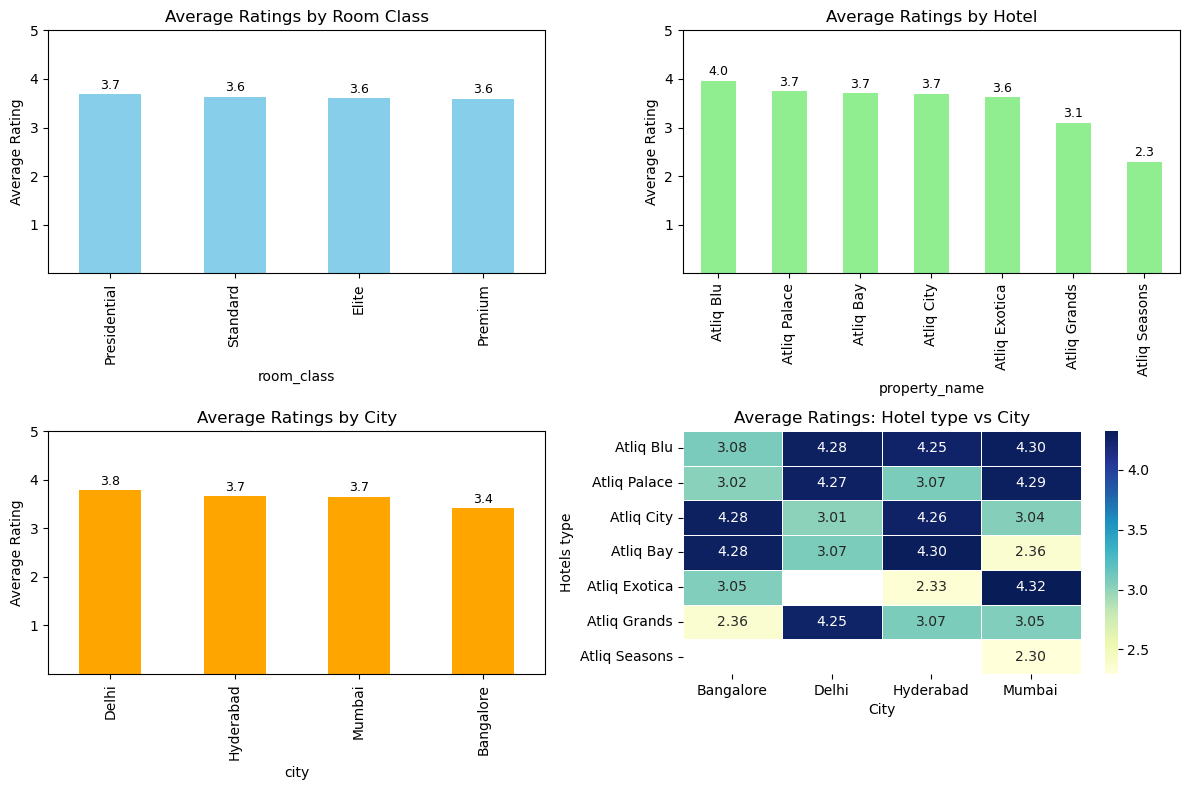

In [29]:
ratings_by_room = df_bookings.groupby('room_class')['ratings_given'].mean().sort_values(ascending=False)
ratings_by_property = df_bookings.groupby('property_name')['ratings_given'].mean().sort_values(ascending=False)
ratings_by_city = df_bookings.groupby('city')['ratings_given'].mean().sort_values(ascending=False)
ratings_by_property_city = df_bookings.groupby(['property_name', 'city'])['ratings_given'].mean().reset_index()

pivot = ratings_by_property_city.pivot(
    index='property_name',
    columns='city',
    values='ratings_given'
)

pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

def plot_vertical(series, ax, title, color):
    series.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Average Rating')
    ax.set_xlabel(series.index.name)
    ax.set_yticks(np.arange(1.0, 6.0, 1.0))
    for i, v in enumerate(series):
        ax.text(i, v + 0.05, f"{v:.1f}", ha='center', va='bottom', fontsize=9)

plot_vertical(ratings_by_room, axes[0, 0], 'Average Ratings by Room Class', 'skyblue')
plot_vertical(ratings_by_property, axes[0, 1], 'Average Ratings by Hotel', 'lightgreen')
plot_vertical(ratings_by_city, axes[1, 0], 'Average Ratings by City', 'orange')

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Average Ratings: Hotel type vs City', fontsize=12)
axes[1, 1].set_xlabel('City')
axes[1, 1].set_ylabel('Hotels type')

plt.tight_layout()
plt.savefig("my_plt2.png")
plt.show()

***Ratings Analysis***

Diving into hotel ratings across room classes, cities, and properties uncovers clear patterns of guest satisfaction. Presidential rooms consistently receive the highest ratings, averaging 3.69, while Premium rooms average slightly lower at 3.59, suggesting that top-tier accommodations are perceived favorably. Across cities, Delhi stands out with the highest overall satisfaction at 3.78, while Bangalore trails at 3.41, signaling potential areas for improvement. Hyderabad and Mumbai fall in between, demonstrating moderate guest satisfaction.

At the hotel level, performance varies further. Atliq Blu impresses with a rating of 3.96, whereas Atliq Seasons lags at 2.30. Location also plays a role: Atliq Exotica scores 4.32 in Mumbai but drops sharply to 2.33 in Hyderabad, while similar variations appear for Atliq Bay and Atliq Blu across cities. These trends indicate that guest satisfaction depends not only on hotel type but also on city-specific factors such as management, service quality, and local expectations.

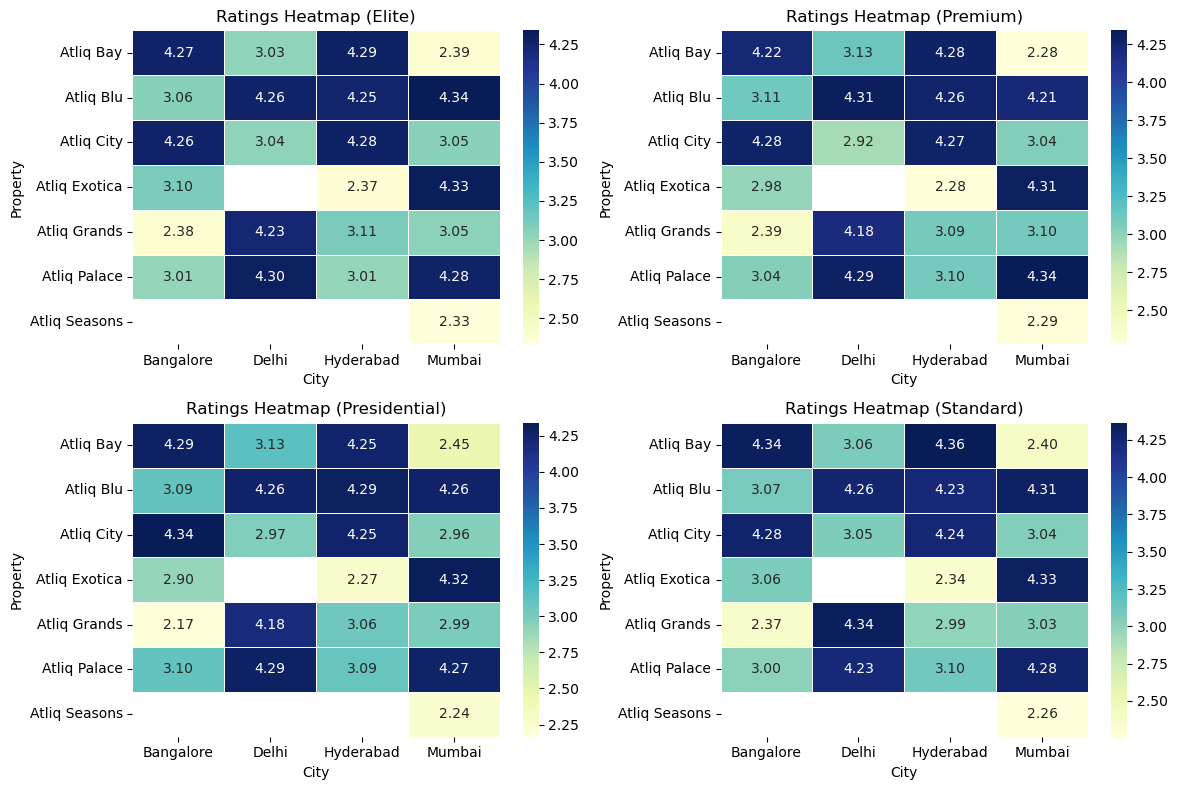

In [30]:
ratings_by_property_city_room_class = df_bookings.groupby(['property_name', 'city', 'room_class'])['ratings_given'].mean().reset_index()
room_classes = ratings_by_property_city_room_class['room_class'].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten() 

for i, room in enumerate(room_classes):
    temp = ratings_by_property_city_room_class[
        ratings_by_property_city_room_class['room_class'] == room
    ]
    pivot = temp.pivot(
        index='property_name',
        columns='city',
        values='ratings_given'
    )
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        linewidths=0.5,
        ax=axes[i]
    )
    axes[i].set_title(f'Ratings Heatmap ({room})')
    axes[i].set_xlabel('City')
    axes[i].set_ylabel('Property')

for j in range(i + 1, 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("my_plt3.png")
plt.show()

***Low-Rating Hotel Types and Urgent Focus***

Examining low-performing properties, certain hotel-type, room-class, and city combinations emerge as urgent focus areas. Atliq Seasons in Mumbai struggles across all room classes, while Atliq Exotica in Hyderabad underperforms in Presidential, Elite, Premium, and Standard rooms. Atliq Grands in Bangalore and Atliq Bay in Mumbai also show concerning ratings in multiple room classes. These patterns suggest systemic challenges likely tied to service quality, amenities, or location-specific factors. Addressing these issues will require a careful investigation of guest feedback, operational processes, and facilities to prioritize interventions and improve service delivery.

/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/4228177136.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


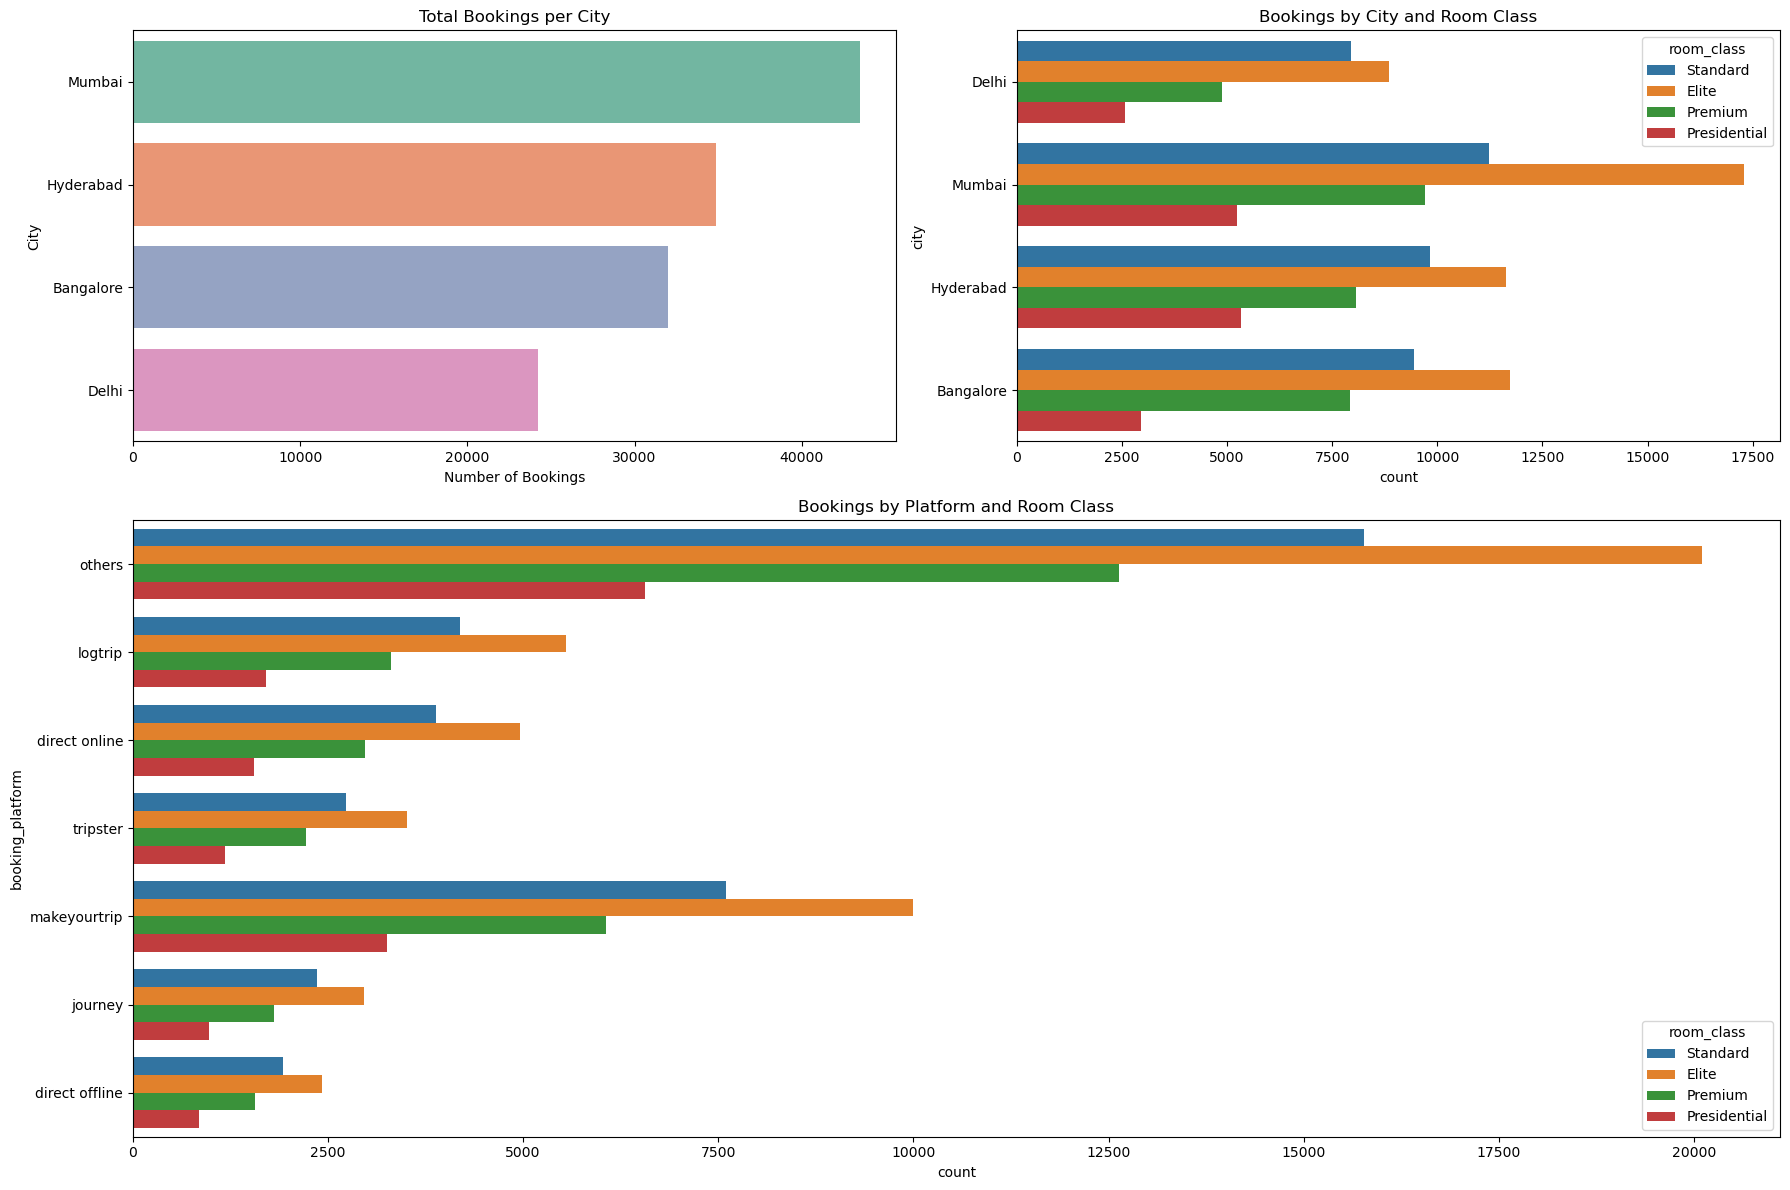

In [31]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.5])  # 2 rows, 2 columns, bottom row bigger

ax0 = fig.add_subplot(gs[0,0])
sns.countplot(
    data=df_bookings,
    y='city',
    order=df_bookings['city'].value_counts().index,
    palette='Set2',
    ax=ax0
)
ax0.set_title('Total Bookings per City')
ax0.set_xlabel('Number of Bookings')
ax0.set_ylabel('City')

ax1 = fig.add_subplot(gs[0,1])
sns.countplot(
    data=df_bookings,
    y='city',
    hue='room_class',
    ax=ax1
)
ax1.set_title('Bookings by City and Room Class')

ax2 = fig.add_subplot(gs[1,:])
sns.countplot(
    data=df_bookings,
    y='booking_platform',
    hue='room_class',
    ax=ax2
)
ax2.set_title('Bookings by Platform and Room Class')

plt.tight_layout()
plt.savefig("my_plt4.png")
plt.show()

***Booking Insights: Room Class and Platform***

Guest preferences reveal a consistent story. Elite rooms dominate bookings across all major cities, reflecting strong demand for premium experiences. Standard and Premium rooms attract moderate interest, while Presidential rooms remain rare, likely reserved for special occasions or corporate stays.

Booking platforms highlight additional patterns. The “others” platform accounts for the majority of reservations, followed by makeyourtrip and logtrip. Across platforms, Elite rooms consistently lead, indicating high-end preferences are stable. Standard and Premium rooms maintain steady bookings, while Presidential rooms continue to see limited adoption.

City-level booking counts reinforce this trend: Mumbai leads with 43,454 bookings, followed by Hyderabad (34,883), Bangalore (32,015), and Delhi (24,226). This shows the core guest base is concentrated in Mumbai. Overall, Elite rooms form the backbone of revenue, while opportunities exist to grow demand for other room types, particularly on underperforming platforms, through targeted promotions or special offers.

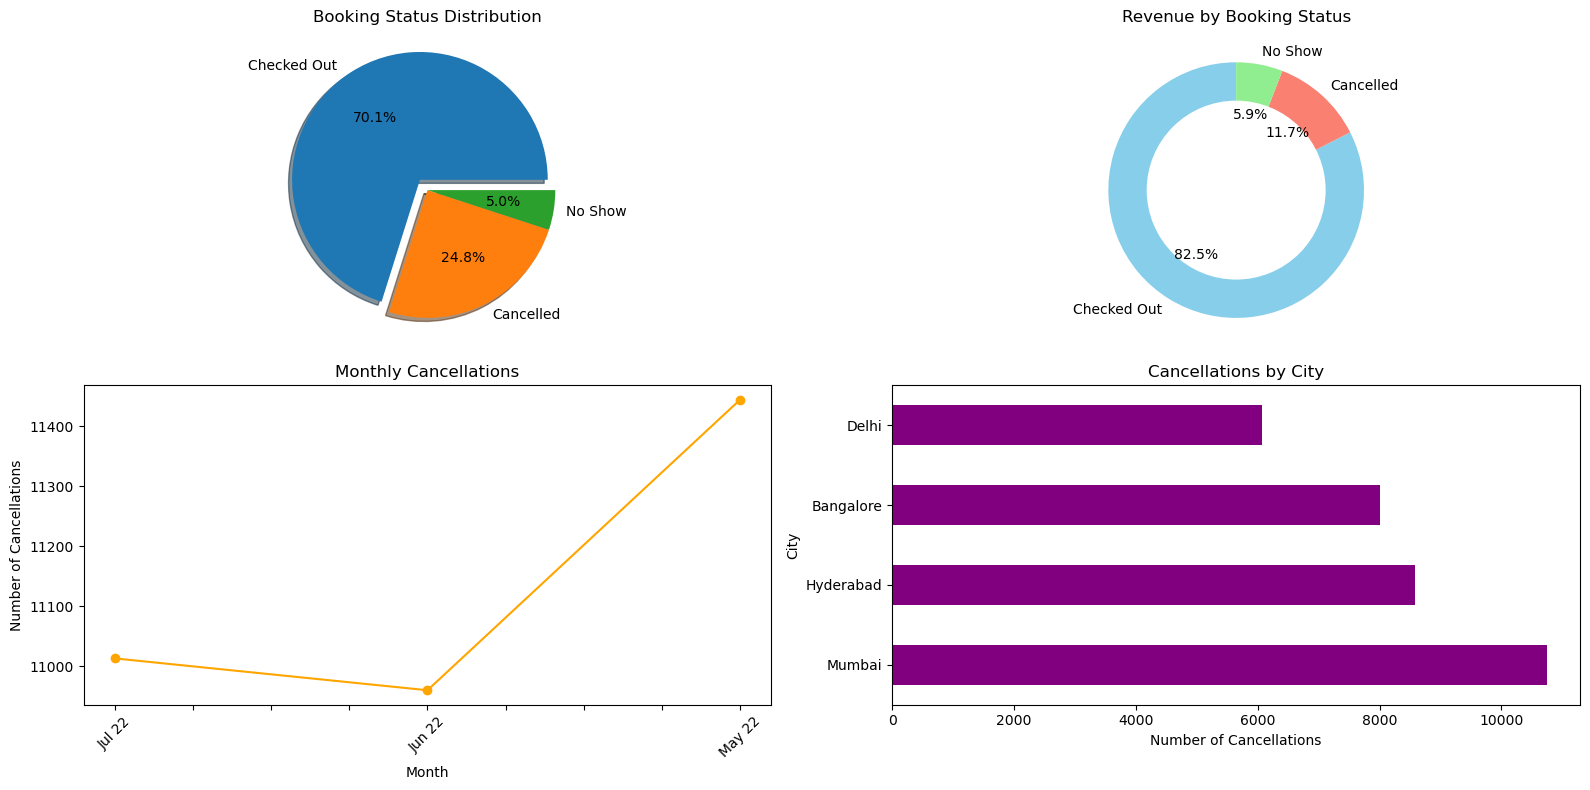

In [32]:
status_counts = df_bookings['booking_status'].value_counts()
status_revenue = df_bookings.groupby('booking_status')['revenue_realized'].sum().sort_values(ascending=False)

monthly_cancellations = df_bookings[df_bookings['booking_status'] == 'Cancelled'].groupby('mmm yy')['day_type'].count()

# Cancellations by city
city_cancellations = df_bookings[df_bookings['booking_status'] == 'Cancelled'].groupby('city')['day_type'].count().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0, 0].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    shadow=True,
    explode=(0.1, 0, 0)
)
axes[0, 0].set_title('Booking Status Distribution')


status_revenue.plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%', startangle=90, colors=['skyblue','salmon','lightgreen'])

centre_circle = plt.Circle((0,0),0.70,fc='white')
axes[0, 1].add_artist(centre_circle)
axes[0, 1].set_ylabel('')
axes[0, 1].set_title('Revenue by Booking Status')

monthly_cancellations.plot(kind='line', ax=axes[1, 0], marker='o', color='orange')
axes[1, 0].set_title('Monthly Cancellations')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Number of Cancellations')
axes[1, 0].tick_params(axis='x', rotation=45)

city_cancellations.plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Cancellations by City')
axes[1, 1].set_xlabel('Number of Cancellations')
axes[1, 1].set_ylabel('City')

plt.tight_layout()
plt.savefig("my_plt5.png")
plt.show()

***Booking Status and Cancellation Analysis***

Analyzing bookings by status highlights the foundation of our revenue. Checked Out bookings dominate with 94,403 completed stays, compared to 33,417 cancellations and 6,758 no-shows. Revenue mirrors this pattern: Checked Out bookings generate 1,408,980,515, far exceeding Cancelled (199,170,324) and No Show (100,453,040) revenue. This confirms that completed stays are the primary revenue drivers, while cancellations and no-shows represent lost opportunities.

Examining cancellations by city, Mumbai leads with 10,754, followed by Hyderabad (8,590), Bangalore (8,002), and Delhi (6,071). Monthly cancellations are relatively consistent, with May at 11,444, June at 10,960, and July at 11,013, suggesting that cancellations are spread across months rather than concentrated.

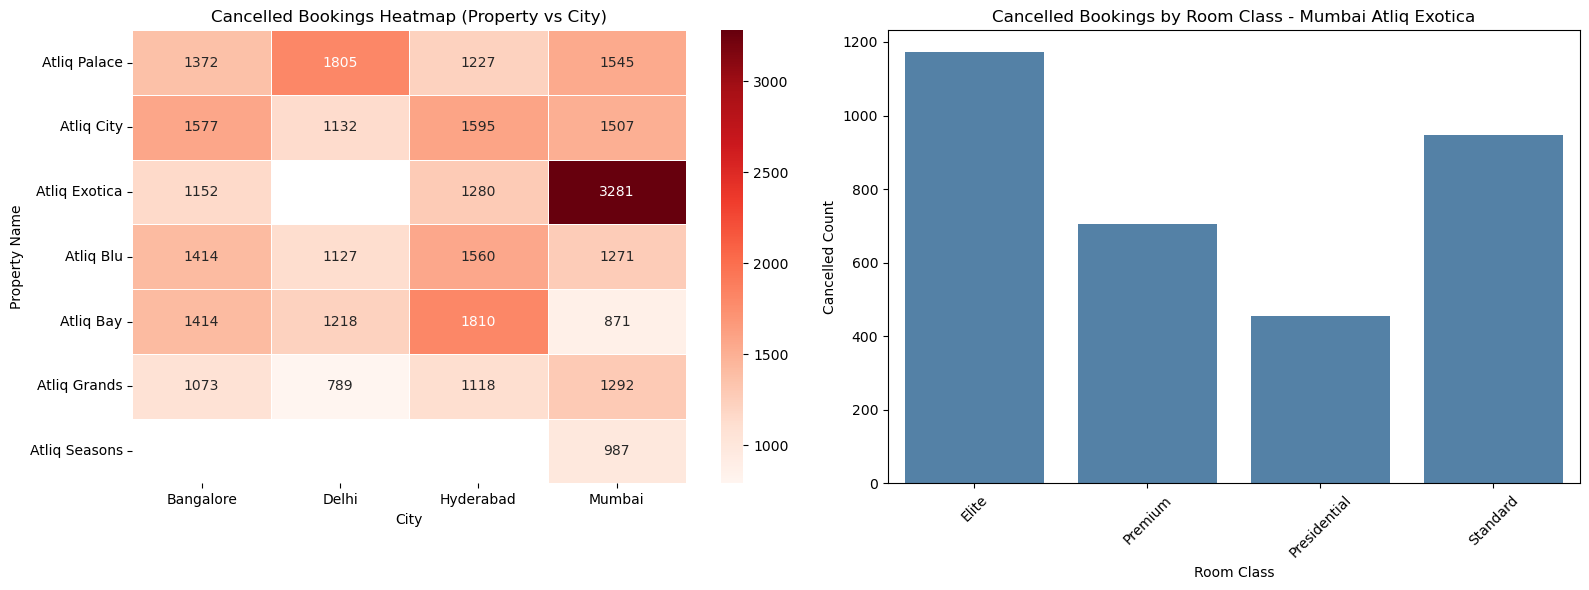

In [33]:
status_counts = df_bookings.groupby(
    ['property_name', 'city', 'booking_status']
).size().reset_index(name='count')

cancelled = status_counts[status_counts['booking_status'] == 'Cancelled']

pivot_cancel = cancelled.pivot(
    index='property_name',
    columns='city',
    values='count'
)
pivot_cancel = pivot_cancel.loc[pivot_cancel.sum(axis=1).sort_values(ascending=False).index]

mumbai_exotica = df_bookings[
    (df_bookings['city'] == 'Mumbai') &
    (df_bookings['property_name'] == 'Atliq Exotica')
]

room_status_counts = mumbai_exotica.groupby(
    ['room_class', 'booking_status']
).size().reset_index(name='count')

cancelled_room = room_status_counts[room_status_counts['booking_status'] == 'Cancelled']


fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.heatmap(
    pivot_cancel,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Cancelled Bookings Heatmap (Property vs City)")
axes[0].set_xlabel("City")
axes[0].set_ylabel("Property Name")

sns.barplot(
    data=cancelled_room,
    x='room_class',
    y='count',
    color='steelblue',   
    ax=axes[1]
)
axes[1].set_title("Cancelled Bookings by Room Class - Mumbai Atliq Exotica")
axes[1].set_xlabel("Room Class")
axes[1].set_ylabel("Cancelled Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("my_plt6.png")
plt.show()


Drilling deeper, cancellations are not evenly distributed across hotels. In Mumbai, Atliq Exotica stands out with 1,173 cancelled Elite room bookings, followed by Standard (948), Premium (704), and Presidential (456). These high-cancellation room classes represent the largest potential revenue loss and highlight where targeted interventions—flexible booking policies, reminders, or promotional incentives—could stabilize bookings and protect revenue.

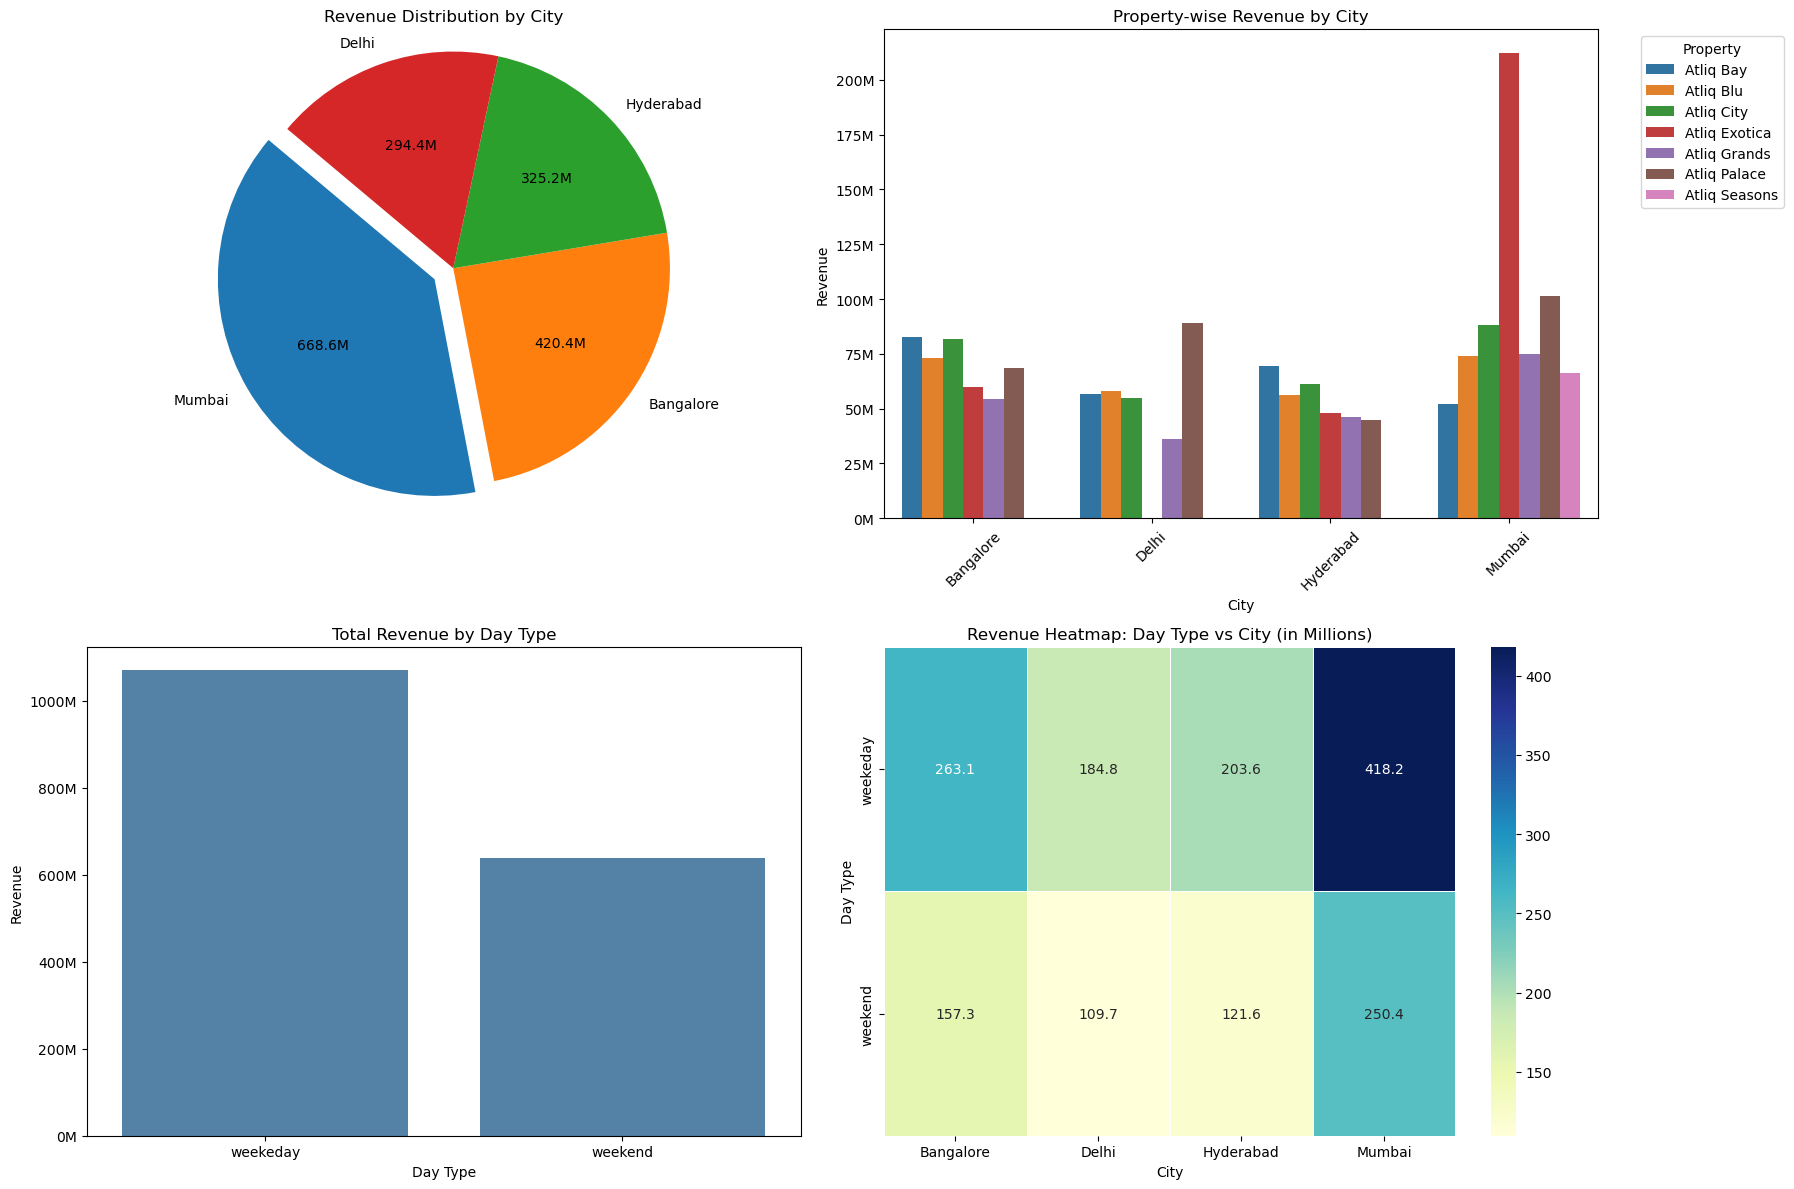

In [34]:
city_revenue = df_bookings.groupby('city')['revenue_realized'].sum().sort_values(ascending=False)

city_property_revenue = df_bookings.groupby(
    ['city', 'property_name']
)['revenue_realized'].sum().reset_index()

revenue_by_day = df_bookings.groupby(
    'day_type'
)['revenue_realized'].sum().sort_values(ascending=False).reset_index()

revenue_day_city = df_bookings.groupby(
    ['day_type','city']
)['revenue_realized'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

def format_revenue(pct, all_values):
    total = sum(all_values)
    value = int(pct * total / 100)
    return f"{value/1_000_000:.1f}M"

axes[0, 0].pie(
    city_revenue,
    labels=city_revenue.index,
    autopct=lambda pct: format_revenue(pct, city_revenue),
    startangle=140,
    explode=[0.1] + [0]*(len(city_revenue)-1)
)
axes[0, 0].set_title('Revenue Distribution by City')
axes[0, 0].axis('equal')

sns.barplot(
    data=city_property_revenue,
    x='city',
    y='revenue_realized',
    hue='property_name',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Property-wise Revenue by City')
axes[0, 1].set_xlabel('City')
axes[0, 1].set_ylabel('Revenue')

axes[0, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
)

axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend(title='Property', bbox_to_anchor=(1.05, 1))

sns.barplot(
    data=revenue_by_day,
    x='day_type',
    y='revenue_realized',
    color='steelblue',
    ax=axes[1, 0]
)

axes[1, 0].set_title("Total Revenue by Day Type")
axes[1, 0].set_xlabel("Day Type")
axes[1, 0].set_ylabel("Revenue")

axes[1, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
)

sns.heatmap(
    revenue_day_city / 1e6,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Revenue Heatmap: Day Type vs City (in Millions)")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Day Type")

plt.tight_layout()
plt.savefig("my_plt7.png")
plt.show()

***Revenue Analysis Summary***

Weekdays consistently generate the bulk of revenue, a trend observed across all cities. At the city level, revenue follows a clear hierarchy: Mumbai leads with 668.6M, followed by Bangalore (420.4M), Hyderabad (325.2M), and Delhi (294.4M). While these figures might suggest underperformance in some cities, a deeper look highlights the impact of portfolio composition. Mumbai’s strong revenue is driven by a concentration of high-performing hotel types, whereas Hyderabad, Delhi, and Bangalore show gaps in certain hotel types or room categories. In other words, a city may seem to underperform not due to low demand, but because the optimal hotel types are not present—a factor explored further in subsequent analysis.

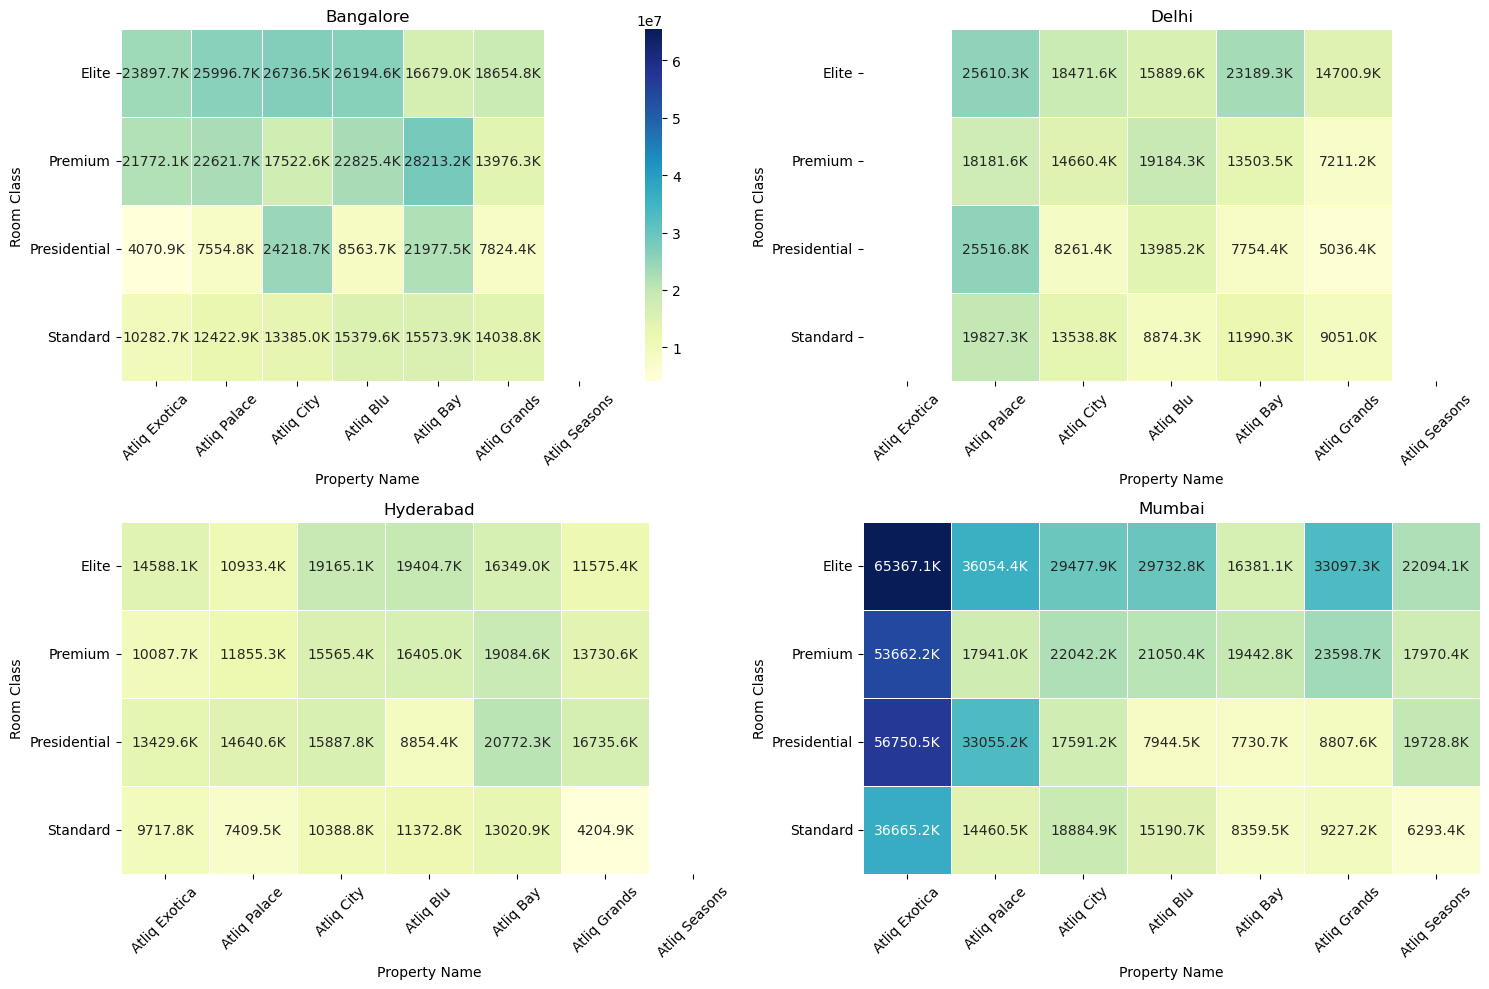

In [35]:
city_property_room_df = df_bookings.groupby(
    ['city', 'property_name', 'room_class']
)['revenue_realized'].sum().reset_index()

cities = city_property_room_df['city'].unique()

property_order = (
    city_property_room_df.groupby('property_name')['revenue_realized']
    .sum()
    .sort_values(ascending=False)
    .index
)

room_order = (
    city_property_room_df.groupby('room_class')['revenue_realized']
    .sum()
    .sort_values(ascending=False)
    .index
)

vmin = city_property_room_df['revenue_realized'].min()
vmax = city_property_room_df['revenue_realized'].max()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, city in enumerate(cities):
    df_city = city_property_room_df[city_property_room_df['city'] == city]


    heatmap_data = df_city.pivot(
        index='room_class',
        columns='property_name',
        values='revenue_realized'
    ).fillna(0)

    heatmap_data = heatmap_data.reindex(index=room_order, columns=property_order)

    annot_labels = heatmap_data.copy()
    for col in annot_labels.columns:
        annot_labels[col] = annot_labels[col].map(lambda x: f"{x/1000:.1f}K")

    sns.heatmap(
        heatmap_data,
        annot=annot_labels,
        fmt="",
        cmap="YlGnBu",
        linewidths=0.5,
        vmin=vmin,
        vmax=vmax,
        cbar=True if i == 0 else False,
        ax=axes[i]
    )
    axes[i].set_title(f'{city}', fontsize=12)
    axes[i].set_ylabel('Room Class')
    axes[i].set_xlabel('Property Name')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("my_plt8.png")
plt.show()

Analyzing revenue by hotel type and room class across cities provides a more granular view of performance. Some hotels consistently drive higher revenue, while certain room classes underperform in specific cities. Examining revenue at both the city and property levels enables us to identify gaps and prioritize strategies for portfolio expansion, rebalancing, and targeted promotions to maximize overall revenue.

/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/481736237.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = heatmap_data.applymap(lambda x: f"{x/1000:.1f}K")
/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/481736237.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/481736237.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/481736237.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variabl

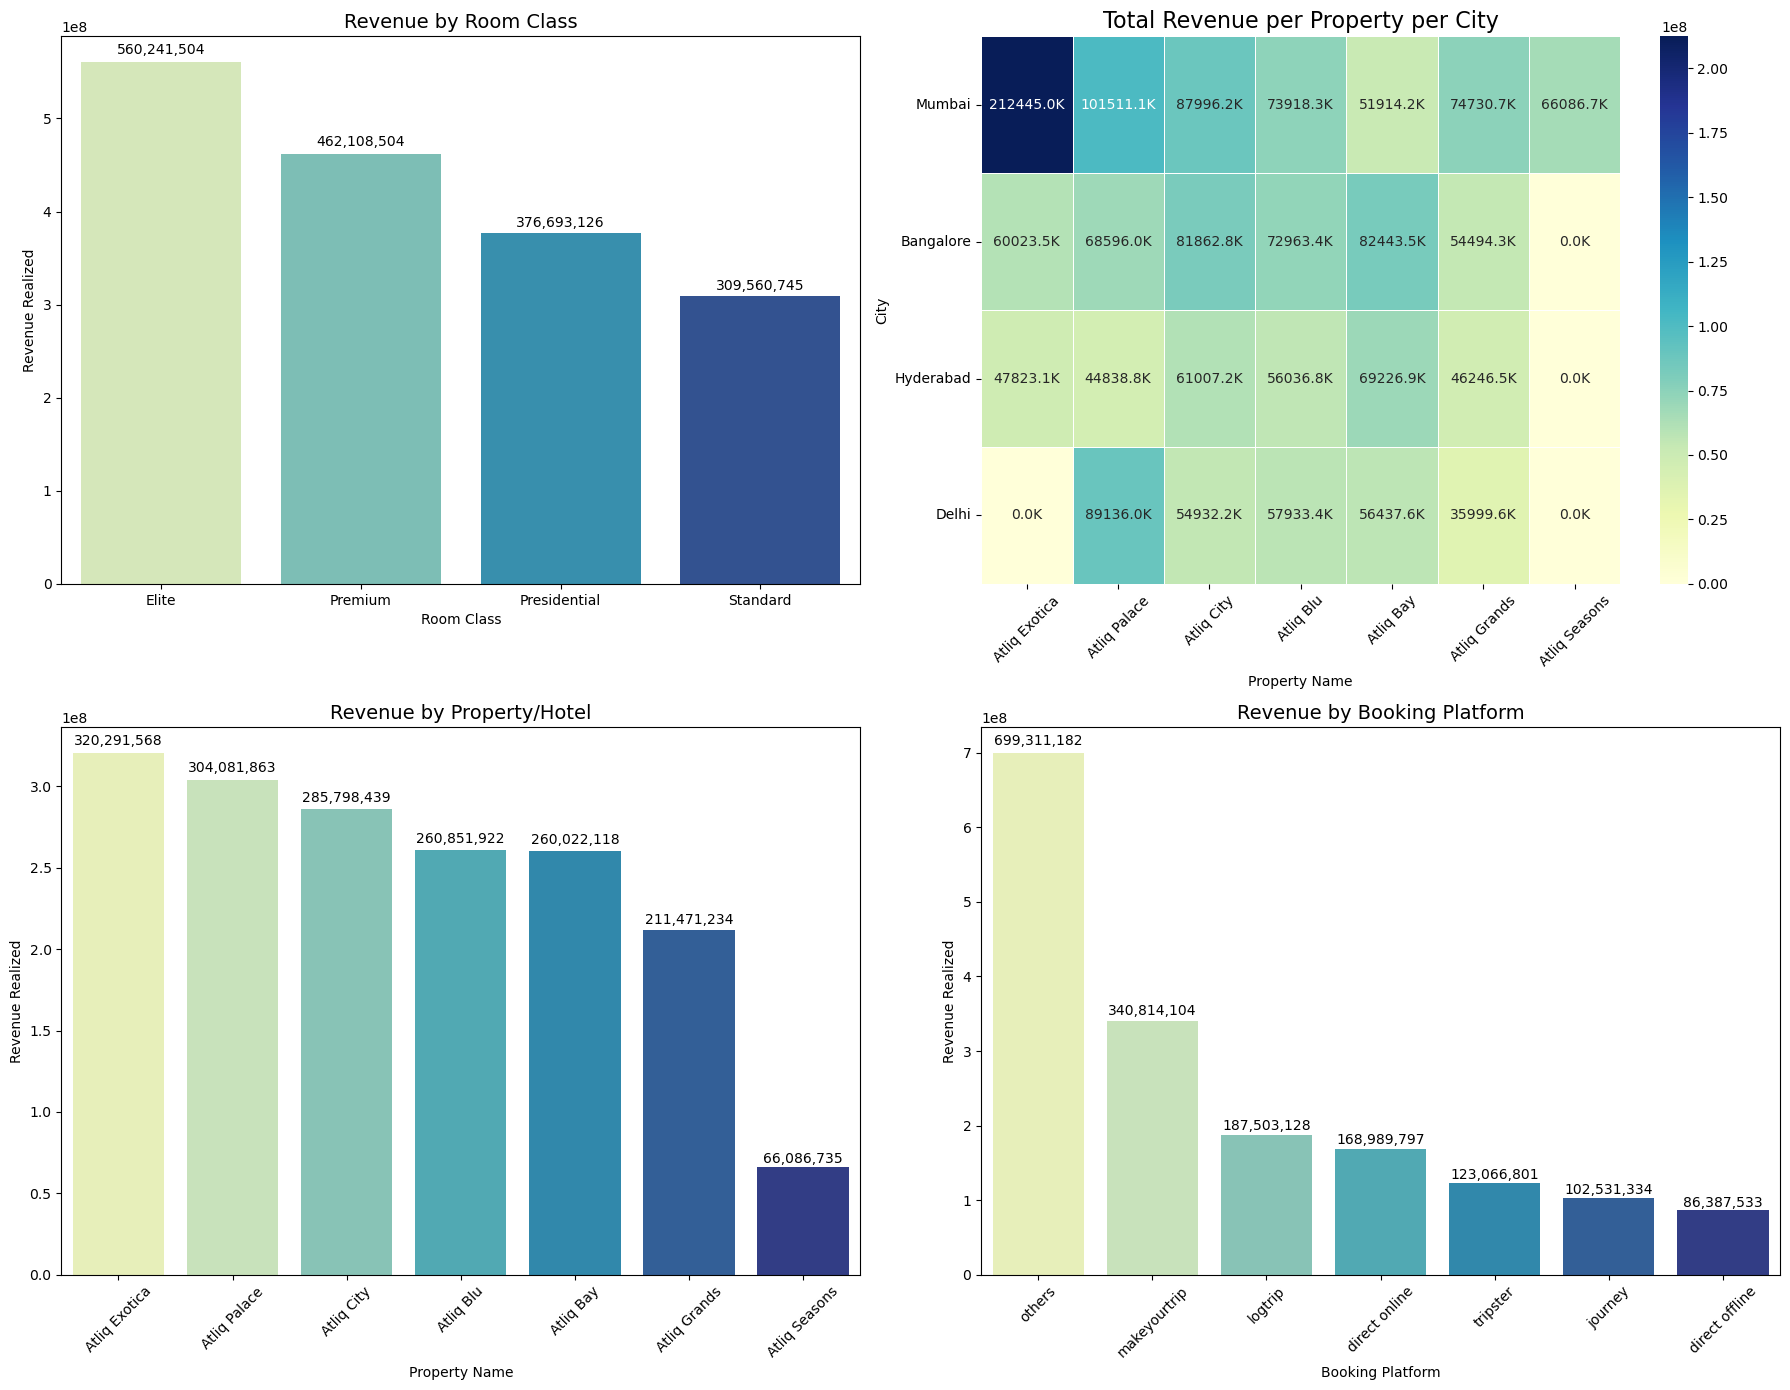

In [36]:
rev_by_room_class = df_bookings.groupby('room_class')['revenue_realized'].sum().sort_values(ascending=False)

city_property_df = df_bookings.groupby(['city', 'property_name'])['revenue_realized'].sum().reset_index()

property_order = (
    city_property_df.groupby('property_name')['revenue_realized']
    .sum()
    .sort_values(ascending=False)
    .index
)
city_order = (
    city_property_df.groupby('city')['revenue_realized']
    .sum()
    .sort_values(ascending=False)
    .index
)
heatmap_data = city_property_df.pivot(
    index='city',
    columns='property_name',
    values='revenue_realized'
).fillna(0)

heatmap_data = heatmap_data.reindex(index=city_order, columns=property_order)
annot_labels = heatmap_data.applymap(lambda x: f"{x/1000:.1f}K")

rev_by_property = df_bookings.groupby('property_name')['revenue_realized'].sum().sort_values(ascending=False)

rev_by_platform = df_bookings.groupby('booking_platform')['revenue_realized'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.barplot(
    x=rev_by_room_class.index,
    y=rev_by_room_class.values,
    palette="YlGnBu",
    ax=axes[0, 0]
)
for i, value in enumerate(rev_by_room_class.values):
    axes[0, 0].text(i, value + value*0.01, f"{value:,.0f}", ha='center', va='bottom', fontsize=10)
axes[0, 0].set_title("Revenue by Room Class", fontsize=14)
axes[0, 0].set_xlabel("Room Class")
axes[0, 0].set_ylabel("Revenue Realized")

sns.heatmap(
    heatmap_data,
    annot=annot_labels,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Total Revenue per Property per City", fontsize=16)
axes[0, 1].set_ylabel("City")
axes[0, 1].set_xlabel("Property Name")
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].tick_params(axis='y', rotation=0)

sns.barplot(
    x=rev_by_property.index,
    y=rev_by_property.values,
    palette="YlGnBu",
    ax=axes[1, 0]
)
for i, value in enumerate(rev_by_property.values):
    axes[1, 0].text(i, value + value*0.01, f"{value:,.0f}", ha='center', va='bottom', fontsize=10)
axes[1, 0].set_title("Revenue by Property/Hotel", fontsize=14)
axes[1, 0].set_xlabel("Property Name")
axes[1, 0].set_ylabel("Revenue Realized")
axes[1, 0].tick_params(axis='x', rotation=45)

sns.barplot(
    x=rev_by_platform.index,
    y=rev_by_platform.values,
    palette="YlGnBu",
    ax=axes[1, 1]
)
for i, value in enumerate(rev_by_platform.values):
    axes[1, 1].text(i, value + value*0.01, f"{value:,.0f}", ha='center', va='bottom', fontsize=10)
axes[1, 1].set_title("Revenue by Booking Platform", fontsize=14)
axes[1, 1].set_xlabel("Booking Platform")
axes[1, 1].set_ylabel("Revenue Realized")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("my_plt9.png")
plt.show()

***Revenue Overview by Room, Property, and Platform***

Exploring revenue by room class, property, and booking platform reveals a clear story. Elite rooms drive the majority of revenue, forming the backbone of the business. Property-level heatmaps show which hotels contribute most in each city, while revenue by hotel type highlights consistently high-performing properties. Revenue by booking platform indicates where marketing and distribution efforts are most effective. Together, these insights provide a holistic view of revenue concentration, performance drivers, and opportunities for growth.

/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/664606735.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = heatmap_data.applymap(lambda x: f"{x/1e6:.1f}M")
/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/664606735.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


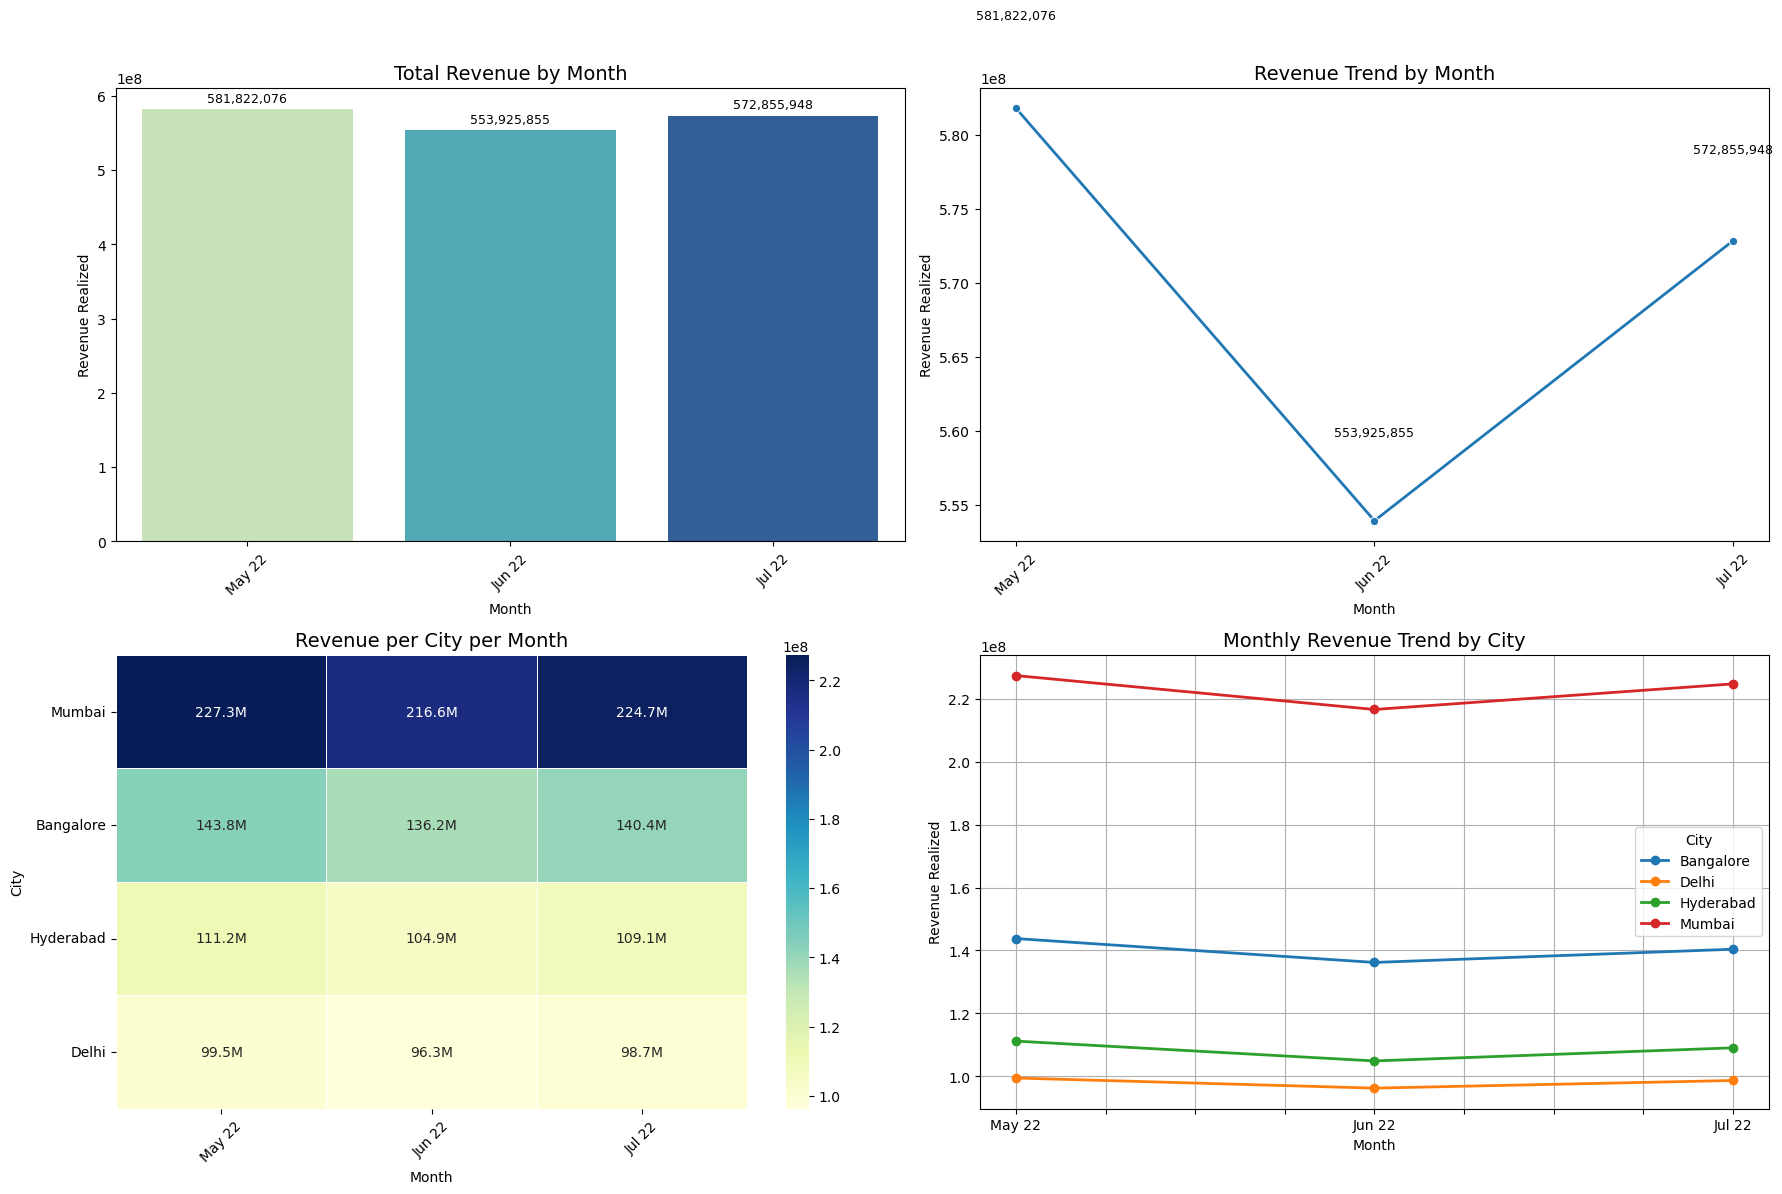

In [37]:
rev_by_month = df_bookings.groupby('mmm yy')['revenue_realized'].sum().reset_index()
rev_by_month['month_order'] = pd.to_datetime(rev_by_month['mmm yy'], format='%b %y')
rev_by_month = rev_by_month.sort_values('month_order')

monthly_city = df_bookings.groupby(['mmm yy', 'city'])['revenue_realized'].sum().reset_index()
monthly_pivot = monthly_city.pivot(index='mmm yy', columns='city', values='revenue_realized').fillna(0)
monthly_pivot = monthly_pivot.loc[rev_by_month['mmm yy']]  # Align order with total revenue

city_order = monthly_city.groupby('city')['revenue_realized'].sum().sort_values(ascending=False).index
heatmap_data = monthly_pivot.reindex(columns=city_order)
annot_labels = heatmap_data.applymap(lambda x: f"{x/1e6:.1f}M")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(
    x=rev_by_month['mmm yy'],
    y=rev_by_month['revenue_realized'],
    palette="YlGnBu",
    ax=axes[0,0]
)
for i, value in enumerate(rev_by_month['revenue_realized']):
    axes[0,0].text(i, value + value*0.01, f"{value:,.0f}", ha='center', va='bottom', fontsize=9)
axes[0,0].set_title("Total Revenue by Month", fontsize=14)
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Revenue Realized")
axes[0,0].tick_params(axis='x', rotation=45)

sns.lineplot(
    data=rev_by_month,
    x='mmm yy',
    y='revenue_realized',
    marker='o',
    linewidth=2,
    ax=axes[0,1]
)
for x, y in zip(rev_by_month['mmm yy'], rev_by_month['revenue_realized']):
    axes[0,1].text(x, y + y*0.01, f"{y:,.0f}", ha='center', va='bottom', fontsize=9)
axes[0,1].set_title("Revenue Trend by Month", fontsize=14)
axes[0,1].set_xlabel("Month")
axes[0,1].set_ylabel("Revenue Realized")
axes[0,1].tick_params(axis='x', rotation=45)

sns.heatmap(
    heatmap_data.T,  
    annot=annot_labels.T,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[1,0]
)
axes[1,0].set_title("Revenue per City per Month", fontsize=14)
axes[1,0].set_xlabel("Month")
axes[1,0].set_ylabel("City")
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].tick_params(axis='y', rotation=0)


monthly_pivot.plot(
    kind='line',
    marker='o',
    linewidth=2,
    ax=axes[1,1]
)
axes[1,1].set_title("Monthly Revenue Trend by City", fontsize=14)
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Revenue Realized")
axes[1,1].grid(True)
axes[1,1].legend(title='City')

plt.tight_layout()
plt.savefig("my_plt10.png")
plt.show()

***Monthly Revenue Insights***

Month-by-month revenue trends uncover interesting patterns. May 2022 peaked at 581.8M, dropped in June to 553.9M, and rebounded in July to 572.9M. The June dip is consistent across all cities—Bangalore, Delhi, Hyderabad, and Mumbai—indicating that it is not tied to a specific market but reflects a broader trend affecting bookings. Monitoring these fluctuations helps identify periods that may require targeted strategies to stabilize revenue.

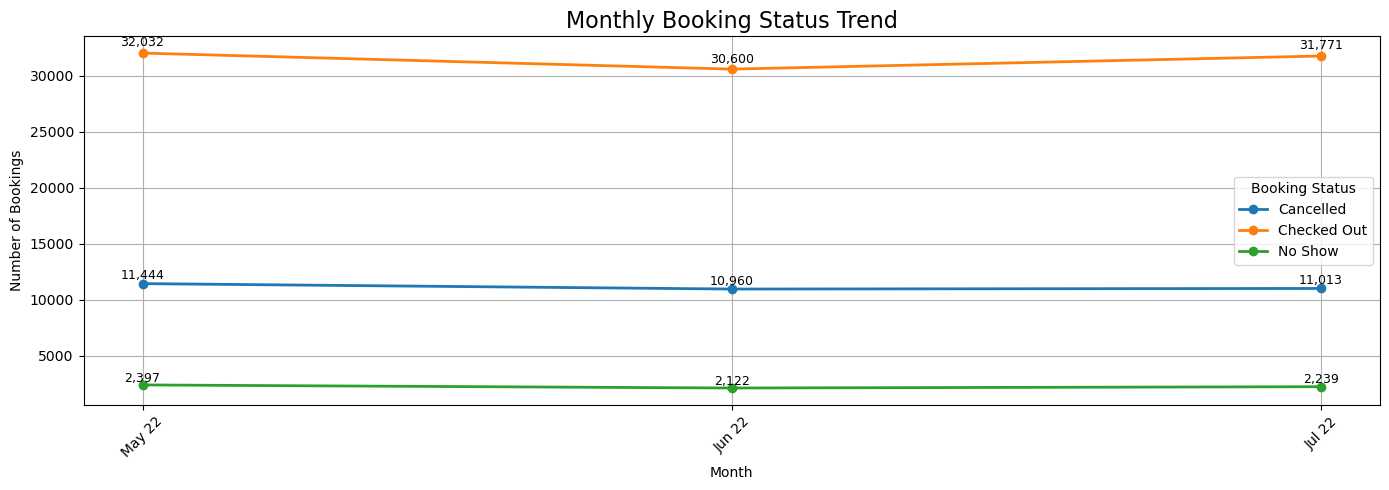

In [38]:
booking_status_month = df_bookings.groupby(['mmm yy', 'booking_status'])['revenue_realized'].count().reset_index()

booking_status_pivot = booking_status_month.pivot(index='mmm yy', columns='booking_status', values='revenue_realized').fillna(0)

booking_status_pivot['month_order'] = pd.to_datetime(booking_status_pivot.index, format='%b %y')
booking_status_pivot = booking_status_pivot.sort_values('month_order')
booking_status_pivot = booking_status_pivot.drop('month_order', axis=1)


plt.figure(figsize=(14,5))
for status in booking_status_pivot.columns:
    plt.plot(
        booking_status_pivot.index,
        booking_status_pivot[status],
        marker='o',
        linewidth=2,
        label=status
    )

for status in booking_status_pivot.columns:
    for x, y in zip(booking_status_pivot.index, booking_status_pivot[status]):
        plt.text(x, y + y*0.01, f"{y:,}", ha='center', va='bottom', fontsize=9)

plt.title("Monthly Booking Status Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Booking Status')
plt.tight_layout()
plt.savefig("my_plt11.png")
plt.show()

***Possible Cause of June Revenue Dip***

Closer inspection shows that the June dip is tied to a slight decline in completed stays. Checked Out bookings fell from 32,032 in May to 30,600 in June. Cancellations and no-shows remained stable, confirming that the drop in revenue is operational rather than market-driven. Understanding this helps clarify that revenue fluctuations are linked to the number of completed stays rather than a change in guest demand.

In [39]:
df_bookings['lead_time'] = df_bookings['check_in_date'] - df_bookings['booking_date']
df_bookings['lead_time'] = df_bookings['lead_time'].dt.days
df_bookings[df_bookings['lead_time'] < 0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,...,room_class,property_name,category,city,successful_bookings,capacity,mmm yy,week no,day_type,lead_time


/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/2129550787.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/83/_9vp9wb55p15wcl3pzvynvxr0000gn/T/ipykernel_92855/2129550787.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


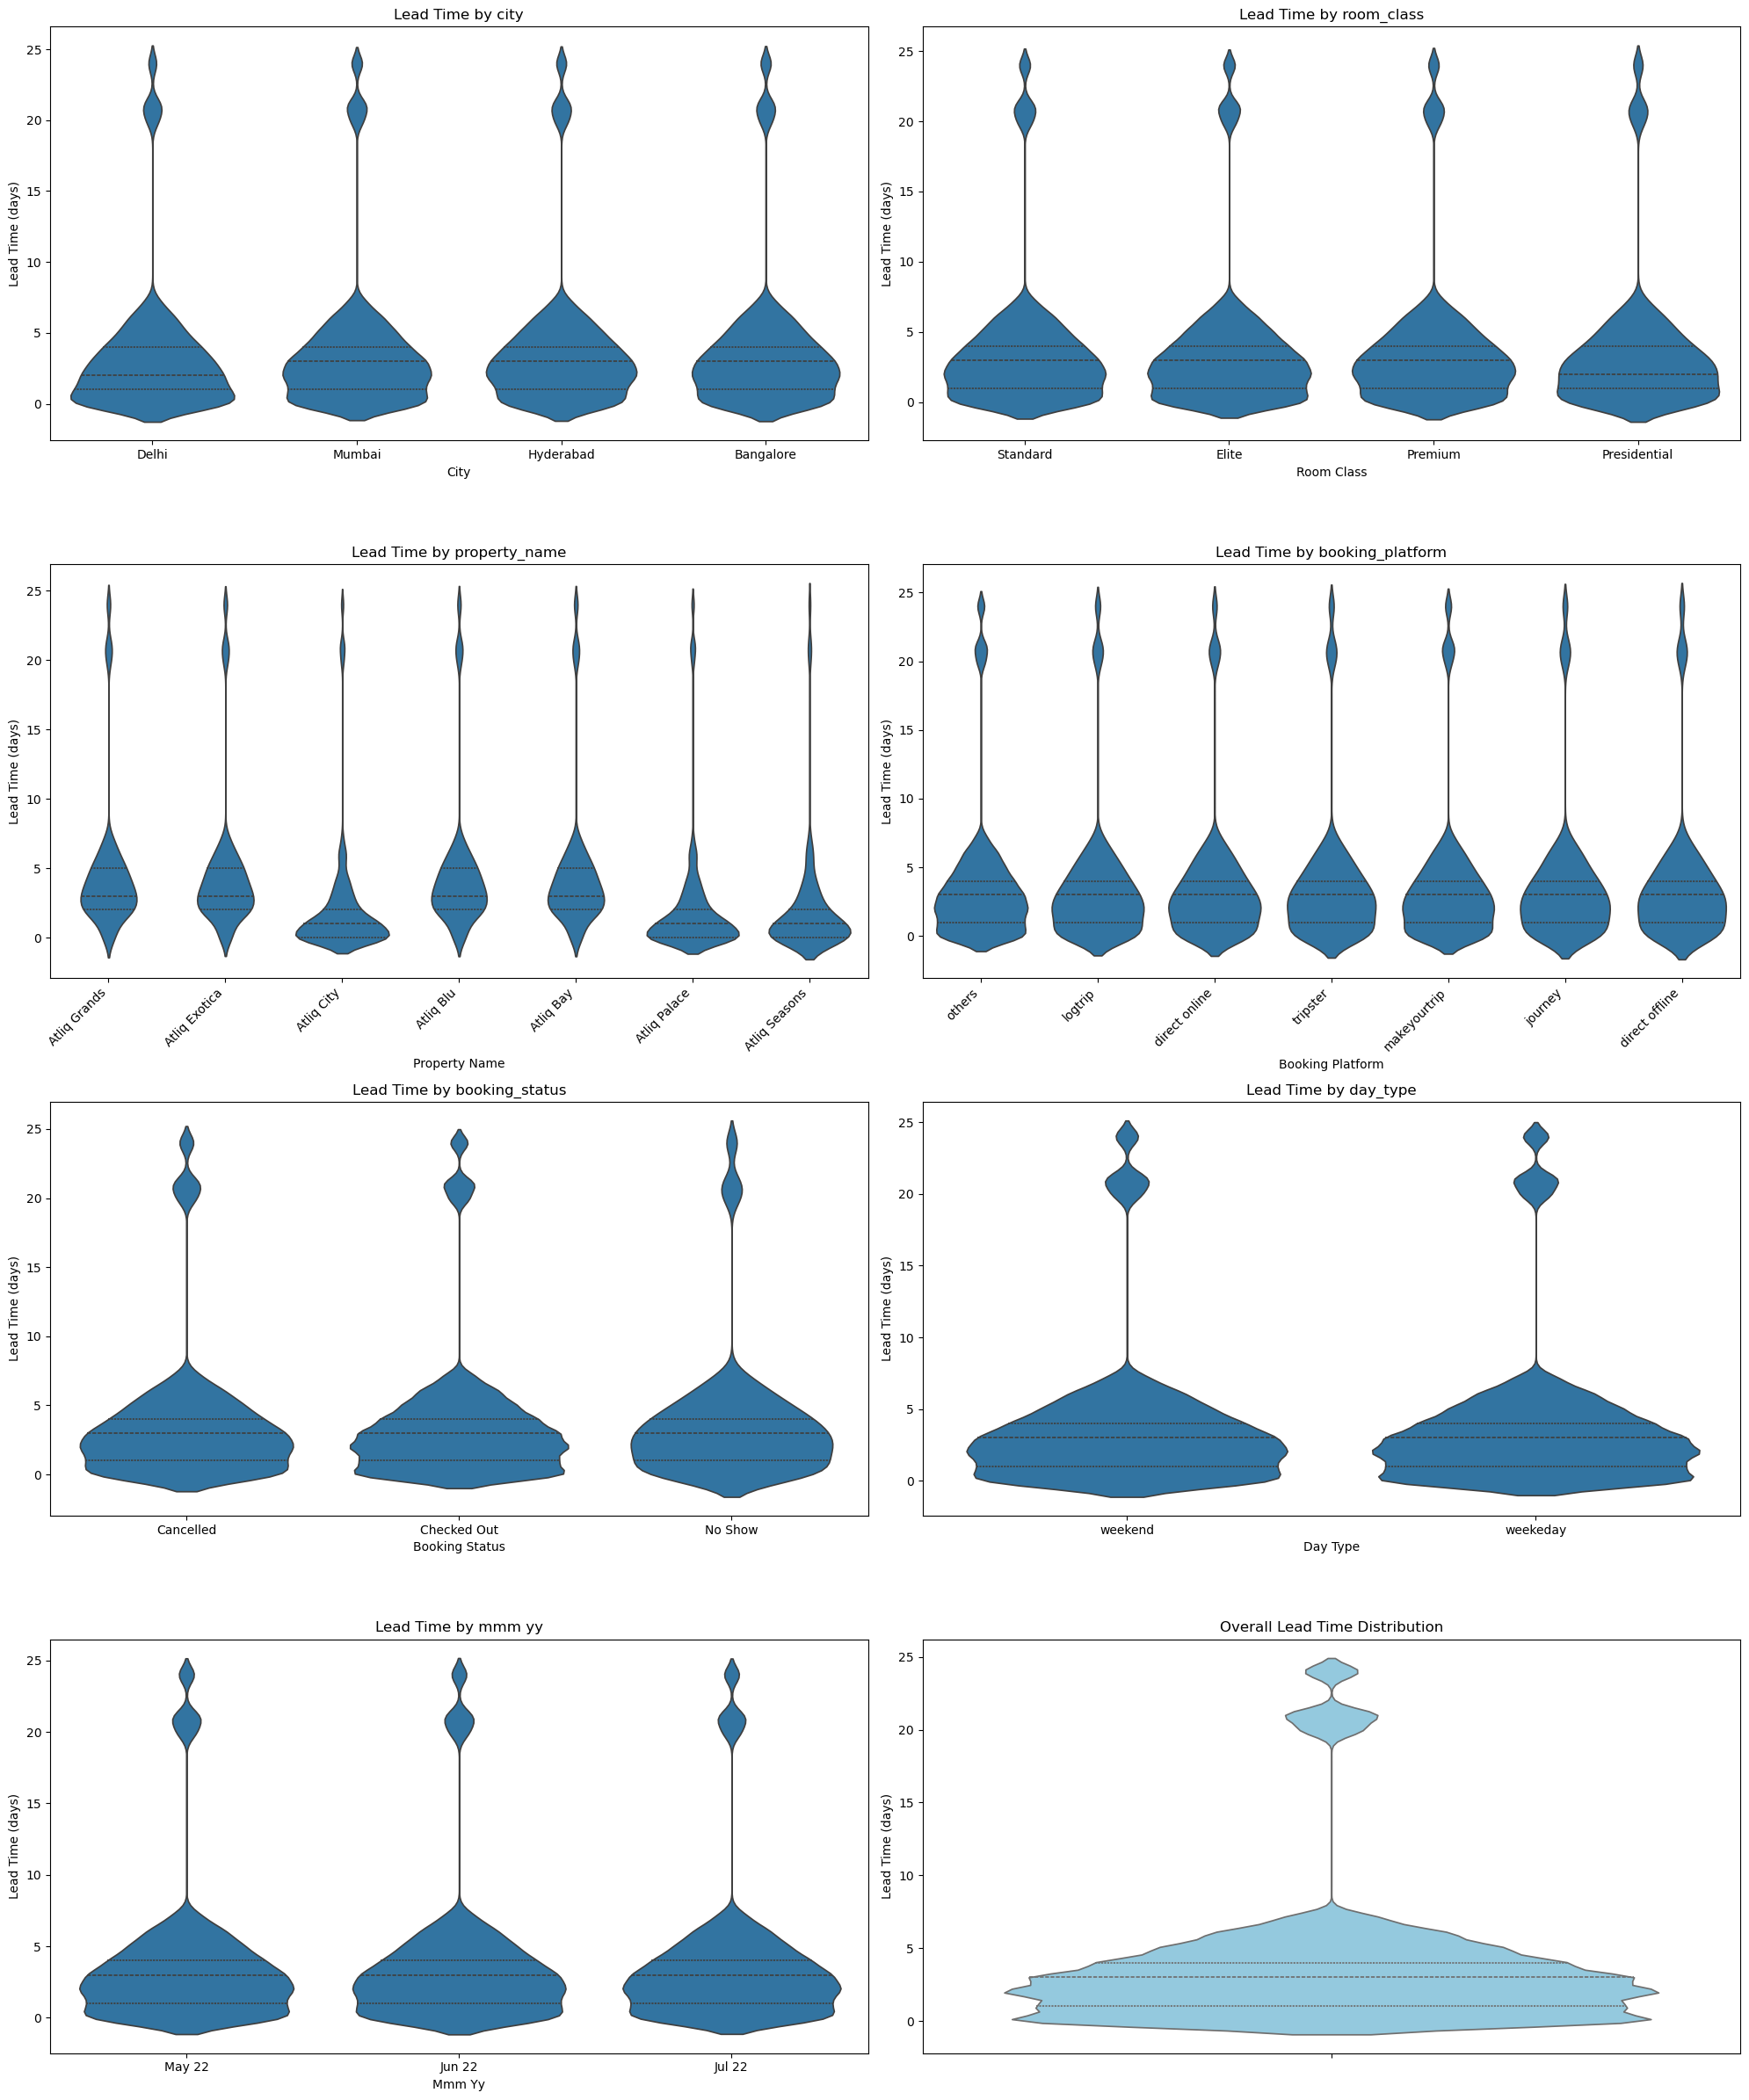

In [40]:
categories = ['city', 'room_class', 'property_name', 'booking_platform',
              'booking_status', 'day_type', 'mmm yy', 'overall']

# Create 4x2 subplot grid
fig, axes = plt.subplots(4, 2, figsize=(20, 24))
axes = axes.flatten()  # flatten 2D array for easy looping

for i, cat in enumerate(categories):
    ax = axes[i]
    
    if cat == 'overall':
        # Overall distribution
        sns.violinplot(y=df_bookings['lead_time'], ax=ax, inner='quartile', color='skyblue')
        ax.set_title('Overall Lead Time Distribution')
        ax.set_xlabel('')
        ax.set_ylabel('Lead Time (days)')
    else:
        sns.violinplot(data=df_bookings, x=cat, y='lead_time', inner='quartile', ax=ax)
        ax.set_title(f'Lead Time by {cat}')
        ax.set_xlabel(cat.replace('_', ' ').title())
        ax.set_ylabel('Lead Time (days)')
        # Rotate x labels if too many categories
        if df_bookings[cat].nunique() > 5:
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig("my_plt12.png")
plt.show()

***Booking Lead Time***

Across cities, room classes, booking platforms, and months, lead time remains stable at 3–4 days. This consistency indicates that changes in guest planning behavior are unlikely to drive revenue fluctuations